# Xây dựng Mini-Transformer Việt - Anh từ đầu (From Scratch) bằng PyTorch

Chào mừng bạn đến với hướng dẫn xây dựng một phiên bản **Mini-Transformer** hoàn chỉnh từ con số không và huấn luyện trên bộ dữ liệu thực tế **IWSLT 2015 (TED Talks) Việt - Anh**! Notebook này được thiết kế theo phong cách kết hợp giữa:
- **Góc nhìn trực quan (Intuitive Visuals)** của bài viết nổi tiếng *"Illustrated Transformer"* (Jay Alammar) để bạn hình dung dòng chảy của các vector và ma trận.
- **Mô hình tương tác (Interactive Mechanics)** của dự án *"Transformer Explainer"* để hiểu cách các token tương tác và liên kết với nhau.
- **Toán học và cài đặt chi tiết** của *"The Annotated Transformer"* (Harvard NLP) để chuyển đổi các công thức toán học thành các dòng code PyTorch thực tế.

Ngoài ra, mô hình này được cấu hình tối ưu để **huấn luyện song song song trên Multi-GPU** (ví dụ: cấu hình **Kaggle GPU T4 x2**), giúp tăng tốc độ huấn luyện đáng kể.

---

## 1. Tổng quan Kiến trúc (Architecture Overview)

Kiến trúc Transformer giới thiệu trong bài báo kinh điển *"Attention Is All You Need"* (2017) đã thay đổi hoàn toàn bộ mặt của Trí tuệ Nhân tạo. Khác với các mô hình tuần tự như RNN hoặc LSTM xử lý thông tin từng bước một và dễ bị quên ngữ cảnh xa, Transformer dựa trên cơ chế **Self-Attention** (Tự chú ý) cho phép xử lý song song toàn bộ các từ trong câu cùng lúc.

Kiến trúc tổng thể gồm hai phần chính:
1. **Encoder (Bộ mã hóa)**: Nhận chuỗi từ đầu vào nguồn (trong bài toán này là **Tiếng Việt**) và ánh xạ chúng thành các biểu diễn vector chứa ngữ cảnh của toàn bộ câu.
2. **Decoder (Bộ giải mã)**: Nhận các vector ngữ cảnh từ Encoder, kết hợp với các từ đã dịch trước đó để sinh ra từ tiếp theo của câu đích (trong bài toán này là **Tiếng Anh**) theo cơ chế tự hồi quy (Autoregressive).

### Sơ đồ luồng dữ liệu tổng quát

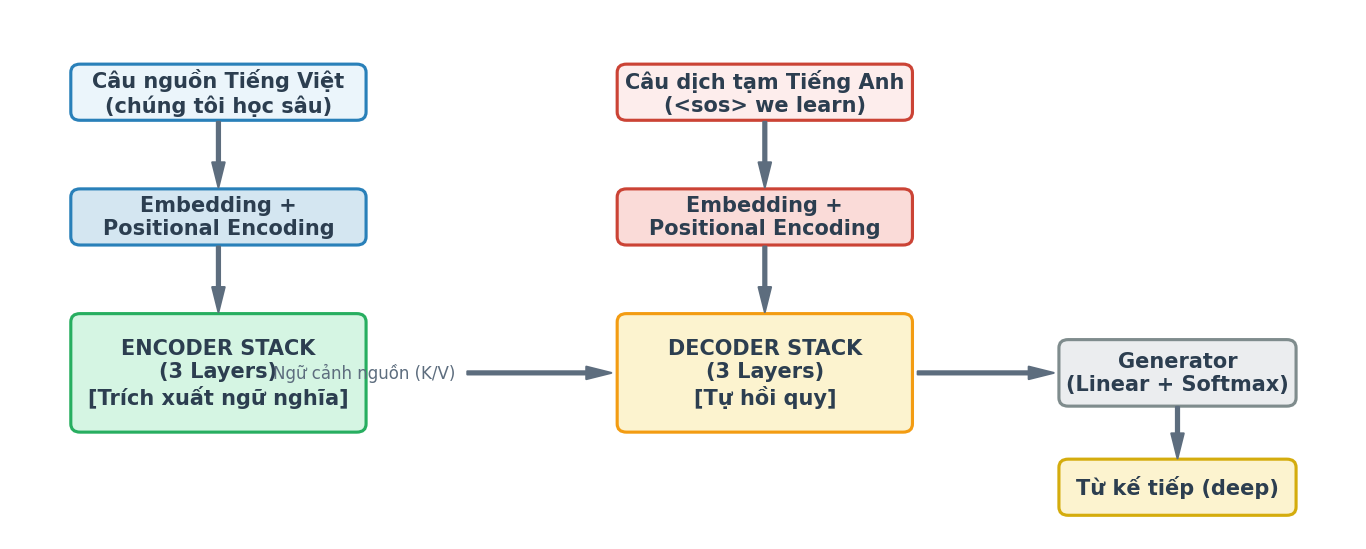


In [ ]:
# Cấu hình môi trường PyTorch giải phóng bộ nhớ phân mảnh
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Cài đặt thư viện datasets của Hugging Face phục vụ tải dữ liệu
!pip install -q datasets matplotlib seaborn numpy torch tokenizers nltk

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datasets import load_dataset

# Thiết lập seed để đảm bảo kết quả huấn luyện có thể tái lập
torch.manual_seed(42)
np.random.seed(42)

# Cấu hình thiết bị (Ưu tiên GPU CUDA nếu có, ngược lại dùng CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Notebook đang chạy trên thiết bị chính: {device}")

# Kiểm tra số lượng GPU khả dụng để chuẩn bị cấu hình huấn luyện song song
num_gpus = torch.cuda.device_count()
print(f"Số lượng GPU khả dụng: {num_gpus}")


## 2. Embeddings & Positional Encoding

### Khái niệm Embeddings
Mô hình học sâu không thể làm việc trực tiếp với văn bản thô. Bước đầu tiên là chuyển đổi mỗi từ (token) thành một chỉ số số nguyên (Token ID), sau đó chiếu chỉ số này vào một không gian vector liên tục $d_{model}$ chiều. Lớp `nn.Embedding` đóng vai trò là một bảng tra cứu, ánh xạ mỗi từ thành một vector biểu diễn ngữ nghĩa của nó.

### Tại sao cần Positional Encoding?
Do Transformer xử lý song song toàn bộ câu cùng một lúc (khác với RNN xử lý tuần tự từ trái sang phải), mô hình **hoàn toàn không có khái niệm về thứ tự hay vị trí của các từ**. Ví dụ, câu *"tôi yêu học máy"* và *"học máy yêu tôi"* sẽ có cùng một tập hợp các vector embedding đầu vào và mô hình sẽ coi chúng là hoàn toàn giống nhau nếu không có thông tin vị trí.

Để giải quyết điểm yếu này, tác giả bài báo đã đề xuất cộng thêm vào vector Embedding của mỗi từ một vector **Positional Encoding (Mã hóa vị trí)** tương ứng với vị trí của từ đó trong câu.

### Sơ đồ luồng cộng Positional Encoding

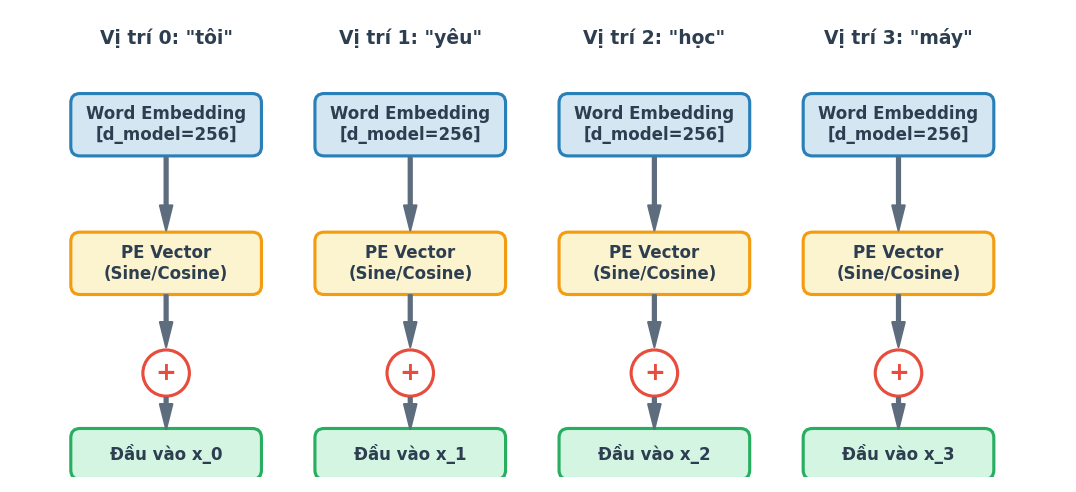

### Công thức Toán học
Công thức Positional Encoding sử dụng các hàm sóng hình sin và hình cosin với các tần số khác nhau:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Trong đó:
- $pos$ là vị trí của từ trong câu ($pos = 0, 1, 2, ..., seq\_len-1$).
- $i$ là chỉ số chiều đặc trưng trong vector ($i = 0, 1, 2, ..., d_{model}/2 - 1$). Cụ thể, các chiều chẵn ($2i$) sử dụng sóng sine, các chiều lẻ ($2i+1$) sử dụng sóng cosine.
- $10000^{2i/d_{model}}$ đóng vai trò là bước sóng. Khi $i$ tăng (đi sâu vào các chiều cuối của vector), bước sóng càng lớn và tần số càng giảm.

**Ý nghĩa trực quan**: Nhờ việc sử dụng các sóng sine/cosine có tần số tuần hoàn khác nhau, mỗi vị trí trong câu sẽ có một chữ ký vector độc nhất. Đồng thời, mô hình có thể dễ dàng học được các mối liên hệ khoảng cách tương đối vì đối với một khoảng cách $k$ cố định, $PE_{pos+k}$ có thể được biểu diễn như một phép biến đổi tuyến tính của $PE_{pos}$.


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # Tạo một ma trận PE kích thước [max_len, d_model] chứa toàn số 0
        pe = torch.zeros(max_len, d_model)
        
        # Tạo vector cột chứa các chỉ số vị trí: [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Tính toán mẫu số của công thức: 10000^(2i/d_model)
        # Áp dụng log-space để tính toán nhanh và ổn định hơn về mặt số học
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Điền các giá trị vào ma trận PE:
        # 0::2 chỉ các cột chẵn: tính bằng hàm sin
        pe[:, 0::2] = torch.sin(position * div_term)
        # 1::2 chỉ các cột lẻ: tính bằng hàm cos
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Thêm một chiều ảo ở đầu tiên đại diện cho batch_size: [1, max_len, d_model]
        # Điều này giúp PyTorch tự động phát sóng (broadcast) khi cộng với tensor đầu vào
        pe = pe.unsqueeze(0)
        
        # Đăng ký ma trận pe như một buffer để PyTorch hiểu đây là một tham số tĩnh của mô hình,
        # được lưu trữ cùng state_dict nhưng không được tính gradient hay tối ưu hóa
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1)]
        return x


### Trực quan hóa ma trận Positional Encoding
Hãy chạy đoạn code dưới đây để vẽ bản đồ nhiệt (heatmap) trực quan hóa ma trận mã hóa vị trí. Bạn sẽ thấy rõ các cột bên trái (chỉ số $i$ nhỏ) biến đổi rất nhanh (tần số cao), trong khi các cột bên phải (chỉ số $i$ lớn) biến đổi rất chậm và mượt mà.


In [ ]:
# Cấu hình các tham số mẫu
d_model_visual = 256
max_len_visual = 50

# Khởi tạo lớp mã hóa vị trí và trích xuất ma trận
pe_layer = PositionalEncoding(d_model=d_model_visual, max_len=max_len_visual)
pe_matrix = pe_layer.pe.squeeze(0).cpu().numpy() # Shape: [max_len, d_model]

# Vẽ đồ thị Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pe_matrix, cmap='coolwarm', cbar=True)
plt.title("Trực quan hóa Bản đồ nhiệt của Positional Encoding Matrix")
plt.xlabel("Chiều vector đặc trưng (d_model Dimension)")
plt.ylabel("Vị trí của Token trong câu (Position)")
plt.show()


## 3. Cơ chế Multi-Head Attention (MHA)

Cơ chế Attention cho phép mô hình tập trung vào các từ quan trọng trong câu khi xử lý một từ cụ thể.

### Scaled Dot-Product Attention
Đây là hạt nhân của cơ chế chú ý. Đầu vào gồm 3 ma trận $Q$ (Query), $K$ (Key), và $V$ (Value):
- **Query ($Q$)**: Đại diện cho từ hiện tại đang truy vấn ngữ cảnh (Tôi đang tìm kiếm thông tin gì?).
- **Key ($K$)**: Đóng vai trò là nhãn khóa của toàn bộ các từ trong câu (Tôi có thông tin gì để khớp?).
- **Value ($V$)**: Giá trị nội dung thực tế của các từ trong câu (Nếu khóa khớp, tôi sẽ truyền đi thông tin gì?).

Công thức toán học tính trọng số chú ý và đầu ra kết quả:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### Sơ đồ luồng Multi-Head Attention

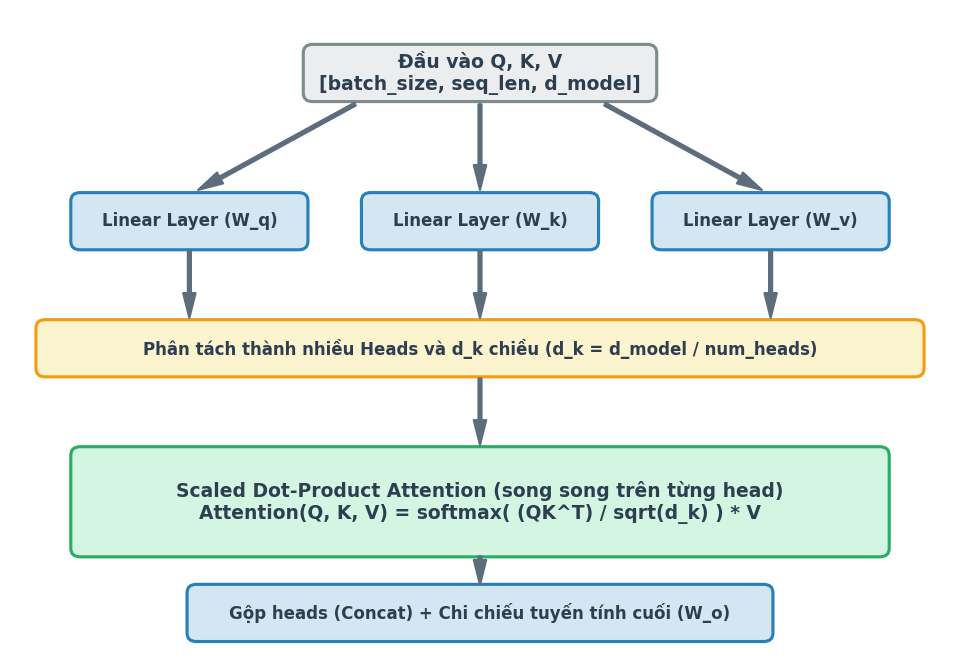

Các bước tính toán chi tiết:
1. **Dot-Product ($QK^T$)**: Nhân vô hướng ma trận Query với chuyển vị của Key để đo đạc mức độ tương quan (độ khớp) giữa từng cặp từ. Kết quả thu được là một ma trận điểm số tương quan (Attention Scores).
2. **Scaling (Chia cho $\sqrt{d_k}$)**: Phép nhân vô hướng sẽ cho ra giá trị rất lớn khi chiều $d_k$ lớn, đẩy hàm Softmax vào vùng cực kỳ bão hòa khiến gradient bị triệt tiêu. Việc chia cho $\sqrt{d_k}$ giữ cho phương sai của phân phối bằng 1, giúp quá trình lan truyền ngược ổn định.
3. **Masking (Tùy chọn)**: Trong Decoder, ta áp dụng cơ chế Masking bằng cách gán các vị trí tương lai bằng $-\infty$ trước khi đi qua Softmax để triệt tiêu trọng số chú ý tại các vị trí đó (hàm Softmax của $-\infty$ bằng $0$).
4. **Softmax**: Ánh xạ các điểm số tương quan thành một phân phối xác suất (tổng bằng 1), đại diện cho tỷ lệ trọng số chú ý.
5. **Nhân với Value**: Lấy ma trận xác suất nhân với Value để thu được trung bình có trọng số của các vector nội dung.

### Multi-Head Attention
Thay vì chỉ tính toán Attention một lần duy nhất trên toàn bộ chiều $d_{model}$ (Single-Head), việc sử dụng **Multi-Head Attention** chiếu tuyến tính $Q, K, V$ thành nhiều không gian con khác nhau. Chúng ta thực hiện tính toán Attention trên từng không gian con này song song độc lập, sau đó ghép (concatenate) kết quả lại và chiếu qua một lớp tuyến tính cuối cùng.

**Tại sao cần Multi-Head?** Điều này tương tự như việc có nhiều bộ lọc trong mạng CNN. Mỗi "head" có thể học cách chú ý đến các khía cạnh ngôn ngữ khác nhau: một head chú ý đến mối quan hệ cú pháp chủ ngữ - động từ, một head chú ý đến mối quan hệ vị trí gần, một head chú ý đến đại từ chỉ định, v.v.


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model phải chia hết cho num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # Số chiều đặc trưng của mỗi head
        
        # Định nghĩa các lớp chiếu tuyến tính cho Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Lớp chiếu tuyến tính đầu ra sau khi nối các heads
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        # q, k, v shape: [batch_size, seq_len, d_model]
        batch_size = q.size(0)
        
        # Bước 1: Chi chiếu tuyến tính các vector Q, K, V
        # Phép biến hình: [batch_size, seq_len, d_model] -> [batch_size, seq_len, num_heads, d_k] -> [batch_size, num_heads, seq_len, d_k]
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Bước 2: Tính Scaled Dot-Product Attention
        # scores shape: [batch_size, num_heads, seq_len_q, seq_len_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Áp dụng mask (nếu có)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e4)
        
        # Trọng số chú ý: [batch_size, num_heads, seq_len_q, seq_len_k]
        # Áp dụng Attention Dropout theo bài báo gốc
        attn_weights = self.dropout(torch.softmax(scores, dim=-1))
        
        # Nhân với Value: [batch_size, num_heads, seq_len_q, d_k]
        context = torch.matmul(attn_weights, V)
        
        # Bước 3: Nối (Concatenate) các head lại với nhau và chiếu tuyến tính đầu ra
        # context shape: [batch_size, seq_len_q, d_model]
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # output shape: [batch_size, seq_len_q, d_model]
        output = self.W_o(context)
        
        return output, attn_weights


## 4. Position-wise Feed-Forward Network (FFN)

Sau khi các token trao đổi thông tin với nhau thông qua lớp Multi-Head Attention, kết quả đầu ra được đưa qua mạng truyền thẳng **Feed-Forward Network (FFN)**. Mạng này được áp dụng một cách độc lập cho từng vị trí từ (Position-wise).

### Vai trò
Lớp Attention bản chất là sự kết hợp tuyến tính thông qua các trọng số. Để mô hình có thể học được các mối quan hệ phi tuyến tính phức tạp và trừu tượng hơn, khối FFN bổ sung thêm tính phi tuyến bằng cách chiếu vector qua hai lớp tuyến tính liên tiếp kết hợp với hàm kích hoạt ReLU ở giữa.

### Công thức Toán học
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

Thông thường, chiều lớp ẩn của FFN ($d_{ff}$) sẽ được mở rộng ra lớn hơn nhiều (gấp 4 lần) so với chiều đặc trưng đầu vào ($d_{model}$), sau đó lớp thứ hai sẽ chiếu giảm số chiều về lại $d_{model}$ để giữ nguyên kích thước dữ liệu truyền lên tầng tiếp theo.


In [ ]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionWiseFeedForward, self).__init__()
        # Lớp tuyến tính thứ nhất (chiếu tăng chiều từ d_model lên d_ff)
        self.w_1 = nn.Linear(d_model, d_ff)
        # Lớp tuyến tính thứ hai (chiếu giảm chiều từ d_ff về lại d_model)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return self.w_2(self.dropout(self.relu(self.w_1(x))))


## 5. Khối Encoder Layer & Decoder Layer

Chúng ta sẽ lắp ghép các thành phần Attention và FFN để tạo thành các khối cơ bản của Encoder và Decoder.

### Residual Connection (Kết nối tắt) & Layer Normalization (Chuẩn hóa lớp)
Để huấn luyện được mô hình Transformer sâu mà không gặp hiện tượng suy giảm hoặc bùng nổ gradient, hai cơ chế quan trọng được tích hợp xung quanh mỗi khối con (Sub-layer):
1. **Residual Connection**: Cộng trực tiếp đầu vào của khối con vào đầu ra của nó: $x + \text{SubLayer}(x)$. Điều này tạo ra một "đường cao tốc" truyền thẳng gradient về các lớp dưới trong quá trình lan truyền ngược.
2. **Layer Normalization**: Chuẩn hóa trung bình và phương sai của các đặc trưng dọc theo chiều ẩn $d_{model}$ độc lập cho từng mẫu, giúp ổn định hóa các phân phối giá trị kích hoạt.

### Pre-LN vs Post-LN
- **Post-LN** (Thiết kế gốc trong bài báo 2017): Áp dụng chuẩn hóa *sau khi* cộng residual: $\text{LayerNorm}(x + \text{SubLayer}(x))$. Thiết kế này làm giảm sự ổn định khi huấn luyện các mô hình sâu do gradient ở các lớp cuối bị chia nhỏ dần, bắt buộc phải dùng các kỹ thuật học khởi động (learning rate warmup) phức tạp.
- **Pre-LN** (Thiết kế hiện đại chuẩn hóa của GPT/LLaMA): Áp dụng chuẩn hóa *trước khi* đi vào khối con và cộng residual trực tiếp: $x + \text{SubLayer}(\text{LayerNorm}(x))$. Trong notebook này, chúng ta sẽ áp dụng **Pre-LN** vì tính ổn định cao và hội tụ nhanh vượt trội.

### Sơ đồ chi tiết cấu trúc Encoder Layer & Decoder Layer (Pre-LN)

| 1. Sơ đồ khối Encoder Layer | 2. Sơ đồ khối Decoder Layer |
| :---: | :---: |
| 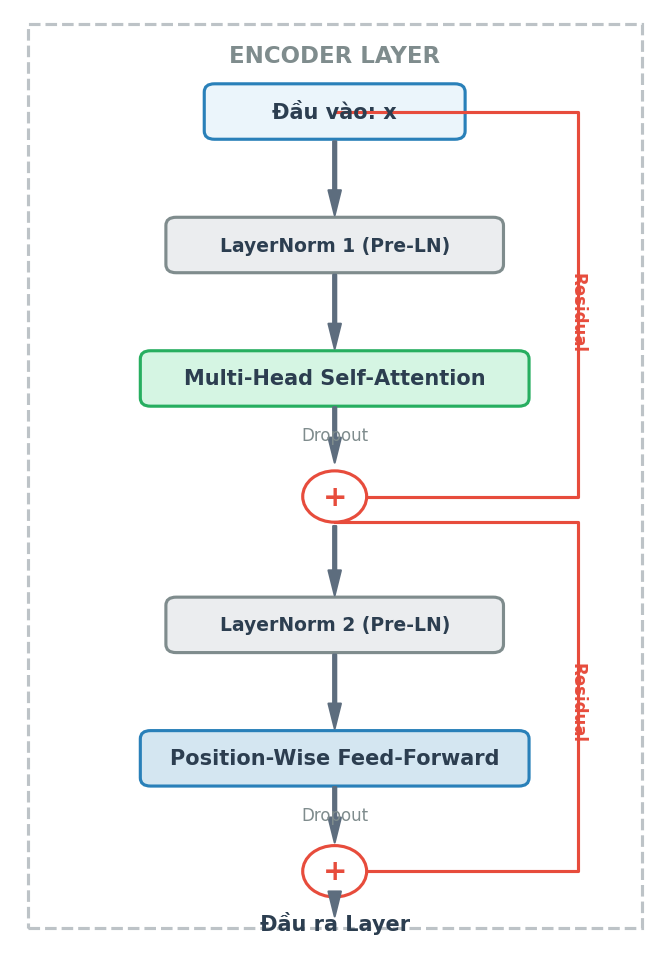 | 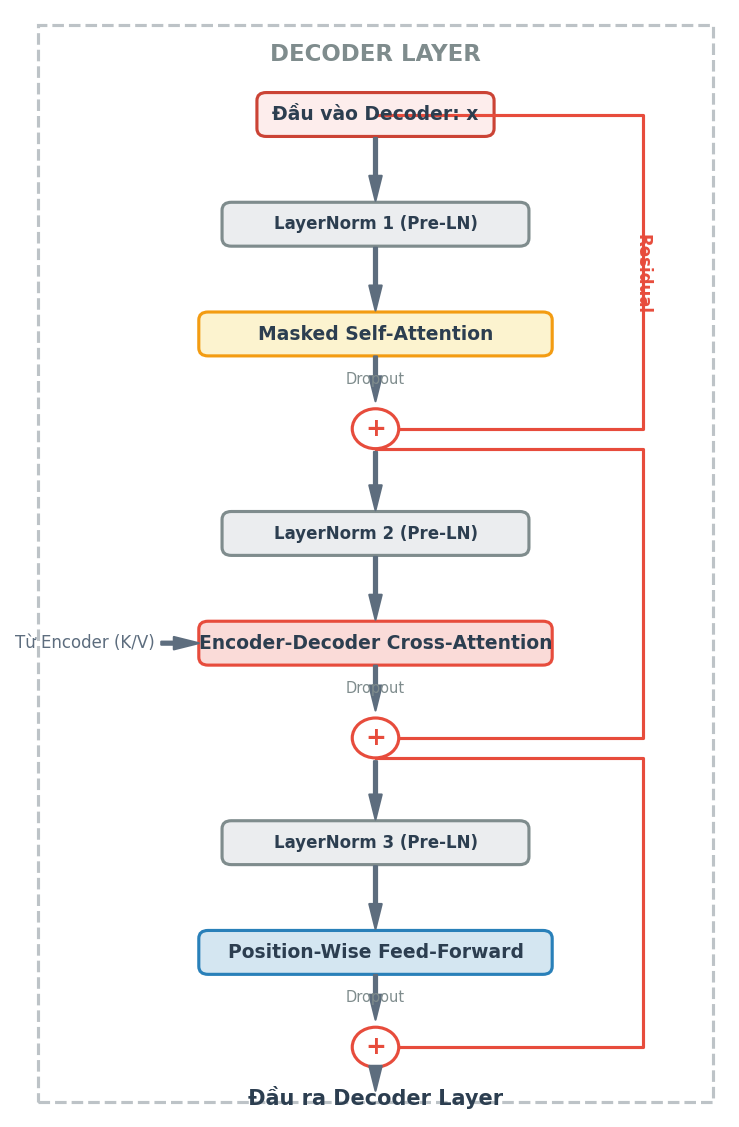 |


In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Khối con 1: Self-Attention kết hợp Pre-LN
        norm_x = self.norm1(x)
        attn_out, attn_weights = self.self_attn(norm_x, norm_x, norm_x, mask)
        x = x + self.dropout(attn_out)
        
        # Khối con 2: Feed-Forward kết hợp Pre-LN
        norm_x = self.norm2(x)
        ff_out = self.feed_forward(norm_x)
        x = x + self.dropout(ff_out)
        
        return x, attn_weights


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # Khối con 1: Masked Self-Attention của Decoder
        norm_x = self.norm1(x)
        self_attn_out, self_attn_weights = self.self_attn(norm_x, norm_x, norm_x, tgt_mask)
        x = x + self.dropout(self_attn_out)
        
        # Khối con 2: Cross-Attention kết nối Decoder và Encoder
        # Query lấy từ Decoder (norm_x), Key và Value lấy từ Encoder (enc_output)
        norm_x = self.norm2(x)
        cross_attn_out, cross_attn_weights = self.cross_attn(norm_x, enc_output, enc_output, src_mask)
        x = x + self.dropout(cross_attn_out)
        
        # Khối con 3: Feed-Forward Network
        norm_x = self.norm3(x)
        ff_out = self.feed_forward(norm_x)
        x = x + self.dropout(ff_out)
        
        return x, self_attn_weights, cross_attn_weights


## 6. Lắp ghép Full Mini-Transformer

Bây giờ, chúng ta sẽ lắp ghép toàn bộ các lớp lại thành các bộ `Encoder` và `Decoder` lớn bằng cách xếp chồng $N$ tầng Encoder Layer và Decoder Layer liên tiếp. Cuối cùng, ta ghép chúng lại thành class `Transformer` hoàn chỉnh.

### Shared Embeddings & Weight Tying (Chia sẻ nhúng & Ràng buộc trọng số)
Để đạt hiệu năng tối ưu nhất theo bài báo gốc, chúng ta huấn luyện một từ vựng BPE chung (Shared Vocabulary) cho cả hai ngôn ngữ. Điều này cho phép thực hiện **Shared Weight Tying** (chia sẻ trọng số đầy đủ) giữa: **Encoder Input Embedding**, **Decoder Input Embedding** và **Generator Linear Layer** (đầu ra pre-softmax), hoàn toàn giống với thiết kế của bài báo gốc. Đồng thời, chúng tôi áp dụng khởi tạo trọng số phân tỷ lệ theo độ sâu (Scaled Initialization cho Pre-LN) giúp ổn định gradient lan truyền.

Ngoài ra, các lớp nhúng (Embeddings) được nhân tỷ lệ (scaled) bởi $\sqrt{d_{model}}$ trước khi cộng với mã hóa vị trí (Positional Encoding).


In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1, embedding=None):
        super(Encoder, self).__init__()
        self.d_model = d_model
        if embedding is not None:
            self.embedding = embedding
        else:
            self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, mask=None):
        # Nhân scale sqrt(d_model) theo bài báo gốc trước khi cộng PE
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        attn_list = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask)
            attn_list.append(attn_weights)
        return self.norm(x), attn_list


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1, embedding=None):
        super(Decoder, self).__init__()
        self.d_model = d_model
        if embedding is not None:
            self.embedding = embedding
        else:
            self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        # Nhân scale sqrt(d_model) theo bài báo gốc trước khi cộng PE
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        self_attn_list = []
        cross_attn_list = []
        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, enc_output, src_mask, tgt_mask)
            self_attn_list.append(self_attn)
            cross_attn_list.append(cross_attn)
        return self.norm(x), self_attn_list, cross_attn_list


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=5000, dropout=0.1):
        super(Transformer, self).__init__()
        self.num_layers = num_layers
        
        # Nếu kích thước từ điển nguồn và đích bằng nhau, ta dùng Shared Embedding
        if src_vocab_size == tgt_vocab_size:
            self.shared_embedding = nn.Embedding(src_vocab_size, d_model)
            self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout, embedding=self.shared_embedding)
            self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout, embedding=self.shared_embedding)
            self.generator = nn.Linear(d_model, tgt_vocab_size, bias=False)
            self.generator.weight = self.shared_embedding.weight
        else:
            self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
            self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
            self.generator = nn.Linear(d_model, tgt_vocab_size, bias=False)
            self.generator.weight = self.decoder.embedding.weight
        
        # Áp dụng khởi tạo trọng số tùy chỉnh trước
        self.apply(self._init_weights)
        
        # Đồng bộ lại Tied Weights sau khởi tạo
        if src_vocab_size == tgt_vocab_size:
            self.generator.weight = self.shared_embedding.weight
        else:
            self.generator.weight = self.decoder.embedding.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
        
        # Khởi tạo trọng số có tỉ lệ (Scaled Initialization cho Pre-LN projection layers)
        if isinstance(module, EncoderLayer) or isinstance(module, DecoderLayer):
            if hasattr(module, 'self_attn') and hasattr(module.self_attn, 'W_o'):
                nn.init.normal_(module.self_attn.W_o.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers))
            if hasattr(module, 'cross_attn') and hasattr(module.cross_attn, 'W_o'):
                nn.init.normal_(module.cross_attn.W_o.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers))
            if hasattr(module, 'feed_forward') and hasattr(module.feed_forward, 'w_2'):
                nn.init.normal_(module.feed_forward.w_2.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers))

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_output, enc_attn = self.encoder(src, src_mask)
        dec_output, dec_self_attn, dec_cross_attn = self.decoder(tgt, enc_output, src_mask, tgt_mask)
        logits = self.generator(dec_output)
        return logits, enc_attn, dec_self_attn, dec_cross_attn


## 7. Xử lý Dữ liệu Lớn Thực tế: IWSLT 2015 (TED Talks) Việt - Anh

Để huấn luyện mô hình trên dữ liệu ngôn ngữ tự nhiên thực tế, chúng ta sử dụng bộ dữ liệu **IWSLT 2015 Việt - Anh** từ Hugging Face có tổng cộng **135,853** cặp câu. Bộ dữ liệu được phân chia theo tỉ lệ chuẩn hóa benchmark như sau:\n- **Train (Huấn luyện)**: 133,317 cặp câu (~98.13%)\n- **Validation (Đánh giá)**: 1,268 cặp câu (~0.93%)\n- **Test (Kiểm thử)**: 1,268 cặp câu (~0.93%)\n\nViệc chuyển sang toàn bộ dữ liệu yêu cầu các kỹ thuật tối ưu hóa xử lý sau:
### 1. Làm sạch văn bản (Text Cleaning) & Giải mã thực thể HTML
Viết hàm `clean_text` thực hiện 3 bước: **(1)** Giải mã các thực thể HTML (`&apos;` → `'`, `&quot;` → `"`) bằng `html.unescape`, **(2)** Chuẩn hóa viết thường, **(3)** Loại bỏ các dấu câu cơ bản `. , ? ! : ; " ' ( ) -` để chuẩn bị cho bước Tokenize.

### 2. Subword Tokenization bằng BPE (Byte Pair Encoding)
Thay vì tách từ theo khoảng trắng (Word-level), chúng ta sử dụng thuật toán **Byte Pair Encoding (BPE)** từ thư viện `tokenizers` của Hugging Face (viết bằng Rust, chạy cực nhanh). BPE tự động học cách chia các từ thành các cụm ký tự con (subwords) dựa trên tần suất xuất hiện trong tập huấn luyện.

**Ưu điểm vượt trội so với Word-level:**
- **Triệt tiêu hoàn toàn token `<unk>`**: Mọi từ mới đều có thể được phân tách thành các subword đã biết.
- **Giảm kích thước từ điển đáng kể**: Từ >30,000 từ thô xuống chỉ còn **16,000 subword tokens**, giúp lớp Embedding và Generator nhỏ gọn hơn.
- **Cải thiện căn chỉnh Attention**: Các đơn vị subword ngắn gọn và nhất quán giúp cơ chế Cross-Attention học được mối liên hệ dịch thuật chính xác hơn.

Các token đặc biệt bao gồm:
- `<pad>` (Index 0): Token đệm các câu ngắn.
- `<sos>` (Index 1): Token bắt đầu chuỗi dịch.
- `<eos>` (Index 2): Token kết thúc chuỗi dịch.
- `<unk>` (Index 3): Token cho từ ngoài từ điển (hiếm khi xuất hiện với BPE).

### 3. PyTorch Dataset và DataLoader
Chúng ta kế thừa lớp `Dataset` để quản lý các cặp câu song ngữ. Khi huấn luyện, ta sử dụng `DataLoader` để tự động chia dữ liệu thành các mini-batches, xáo trộn (`shuffle=True`) dữ liệu sau mỗi epoch.

### 4. Dynamic Padding (Đệm động) qua `collate_fn`
**Một kỹ thuật tối ưu hóa bộ nhớ cốt lõi**: Thay vì đệm tất cả các câu trong toàn bộ dataset về cùng một độ dài tối đa cố định (Static Padding, ví dụ $100$ tokens), chúng ta viết một hàm gom nhóm tùy chỉnh `collate_fn`. Hàm này sẽ tìm độ dài lớn nhất của câu *trong mini-batch hiện tại* và thực hiện đệm các câu ngắn hơn trong mini-batch đó về đúng chiều dài này.
Điều này giúp giảm thiểu cực lớn số lượng token `<pad>` vô nghĩa, giảm bộ nhớ tiêu thụ và tăng tốc độ huấn luyện lên gấp nhiều lần.

### Sơ đồ trực quan Dynamic Padding so với Static Padding

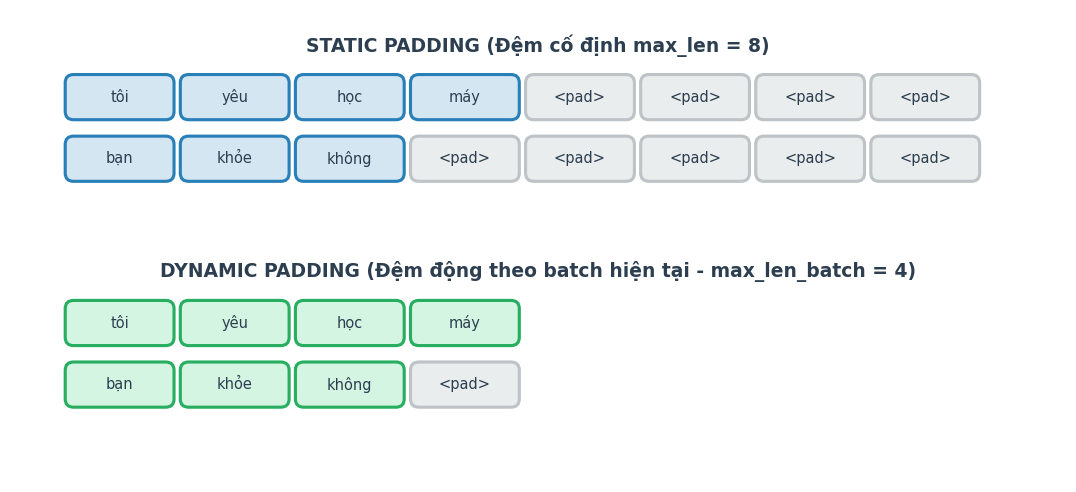


In [ ]:
import html
from tokenizers import Tokenizer, normalizers
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFKC, Lowercase

def clean_text(text):
    text = html.unescape(text)  # Giải mã thực thể HTML: &apos; -> ', &quot; -> "
    text = text.strip().lower()
    # Giữ lại các dấu câu cơ bản để hỗ trợ dịch chính xác hơn, chỉ chuẩn hóa unicode và dấu ngoặc
    text = re.sub(r"[“”“«»]", "\"", text)
    text = re.sub(r"[‘’`´]", "'", text)
    text = re.sub(r"[–—]", "-", text)
    return text

class BPETokenizer:
    def __init__(self, vocab_size=18000, model_path=None):
        self.vocab_size = vocab_size
        if model_path:
            self.tokenizer = Tokenizer.from_file(model_path)
        else:
            self.tokenizer = Tokenizer(BPE(unk_token="<unk>"))
            # Sử dụng NFKC Normalizer tích hợp của Hugging Face để chuẩn hóa ký tự tiếng Việt
            self.tokenizer.normalizer = normalizers.Sequence([NFKC(), Lowercase()])
            self.tokenizer.pre_tokenizer = Whitespace()
            self.trainer = BpeTrainer(
                special_tokens=["<pad>", "<sos>", "<eos>", "<unk>"],
                vocab_size=self.vocab_size
            )

    def train(self, sentences):
        cleaned = [clean_text(s) for s in sentences]
        self.tokenizer.train_from_iterator(cleaned, self.trainer)

    def encode(self, sentence, add_special=True):
        cleaned = clean_text(sentence)
        ids = self.tokenizer.encode(cleaned).ids
        if add_special:
            ids = [1] + ids + [2]  # <sos>=1, <eos>=2
        return ids

    def decode(self, ids):
        filtered = [idx for idx in ids if idx not in [0, 1, 2]]
        return self.tokenizer.decode(filtered)

    @property
    def word2idx(self):
        return {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}

    @property
    def idx2word(self):
        class _IdToToken:
            def __init__(self, tok):
                self.tok = tok
            def __getitem__(self, idx):
                val = self.tok.id_to_token(idx)
                return val if val is not None else "<unk>"
            def get(self, idx, default="<unk>"):
                val = self.tok.id_to_token(idx)
                return val if val is not None else default
        return _IdToToken(self.tokenizer)

    def __len__(self):
        return self.tokenizer.get_vocab_size()


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, raw_data, max_len=None):
        self.pairs = []
        for item in raw_data:
            src = item['vi']
            tgt = item['en']
            if max_len is not None:
                if len(src.split()) > max_len or len(tgt.split()) > max_len:
                    continue
            self.pairs.append((src, tgt))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

class BucketBatchSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, batch_size, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = list(range(len(dataset)))
        # Sắp xếp các câu theo chiều dài của câu nguồn (tiếng Việt)
        self.indices.sort(key=lambda idx: len(dataset.pairs[idx][0].split()))
        
    def __iter__(self):
        # Tạo các batches từ danh sách đã sắp xếp để giảm thiểu padding
        batches = [self.indices[i:i + self.batch_size] for i in range(0, len(self.indices), self.batch_size)]
        if self.shuffle:
            np.random.shuffle(batches)
        for batch in batches:
            yield batch
            
    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

def get_collate_fn(src_vocab, tgt_vocab):
    def collate_fn(batch):
        src_batch, tgt_batch = [], []
        for src_sent, tgt_sent in batch:
            src_batch.append(src_vocab.encode(src_sent, add_special=False))
            tgt_batch.append(tgt_vocab.encode(tgt_sent, add_special=True))
        
        max_src_len = max(len(s) for s in src_batch)
        max_tgt_len = max(len(t) for t in tgt_batch)
        
        padded_src = [s + [0] * (max_src_len - len(s)) for s in src_batch]
        padded_tgt = [t + [0] * (max_tgt_len - len(t)) for t in tgt_batch]
        
        return torch.tensor(padded_src, dtype=torch.long), torch.tensor(padded_tgt, dtype=torch.long)
    return collate_fn


In [ ]:
print("1/3. Đang tải bộ dữ liệu IWSLT 2015 Việt - Anh...")
raw_dataset = load_dataset("thainq107/iwslt2015-en-vi")

print("2/3. Đang trích xuất câu và huấn luyện BPE Tokenizer chung (Shared Vocabulary)...")
vi_train_sentences = [item['vi'] for item in raw_dataset['train']]
en_train_sentences = [item['en'] for item in raw_dataset['train']]

# Huấn luyện một tokenizer BPE chung trên sự kết hợp của cả hai ngôn ngữ
shared_vocab = BPETokenizer(vocab_size=18000)
shared_vocab.train(vi_train_sentences + en_train_sentences)

shared_vocab.tokenizer.save("tokenizer.json")
print("Đã lưu tokenizer thành công vào tệp 'tokenizer.json'!")

src_vocab = shared_vocab
tgt_vocab = shared_vocab

print(f"   -> Kích thước từ điển BPE chung (Shared Vocabulary): {len(shared_vocab)}")
print(f"   -> Số lượng câu tập Train: {len(raw_dataset['train'])}")
print(f"   -> Số lượng câu tập Validation: {len(raw_dataset['validation'])}")
print(f"   -> Số lượng câu tập Test: {len(raw_dataset['test'])}")

print("3/3. Đang thiết lập Dataset và DataLoader với BucketBatchSampler...")
train_dataset = TranslationDataset(raw_dataset['train'], max_len=100)
val_dataset = TranslationDataset(raw_dataset['validation'])
collate_fn = get_collate_fn(src_vocab, tgt_vocab)

train_sampler = BucketBatchSampler(train_dataset, batch_size=32, shuffle=True)
val_sampler = BucketBatchSampler(val_dataset, batch_size=32, shuffle=False)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, collate_fn=collate_fn)


## 8. Cấu hình Huấn luyện Song song (Multi-GPU) & Vòng lặp Huấn luyện

### Thiết kế Mask tương thích Multi-GPU (Device-Aware Masking)
**Một lưu ý kỹ thuật cực kỳ quan trọng khi lập trình đa GPU**: Khi sử dụng `nn.DataParallel`, các phần của một batch sẽ tự động được gửi đến các GPU khác nhau (ví dụ: GPU 0 và GPU 1). Nếu các ma trận mask (`src_mask`, `tgt_mask`) được tạo trên một device cố định (ví dụ `cuda:0`), hệ thống sẽ phát sinh lỗi mismatch device khi xử lý dữ liệu ở GPU 1 (`cuda:1`).
Để giải quyết triệt để vấn đề này, các hàm tạo mask của chúng ta sẽ được định nghĩa để **tạo mask trên cùng thiết bị (device) với tensor dữ liệu đầu vào** bằng cách sử dụng thuộc tính `.device` của chính tensor đó (`.to(src.device)` và `.to(tgt.device)`).


In [ ]:
def make_src_mask(src, pad_idx=0):
    src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)
    return src_mask.to(src.device)

def make_tgt_mask(tgt, pad_idx=0):
    tgt_pad_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
    seq_len = tgt.size(1)
    no_peak_mask = torch.tril(torch.ones((seq_len, seq_len), device=tgt.device)).bool()
    no_peak_mask = no_peak_mask.unsqueeze(0).unsqueeze(1)
    tgt_mask = tgt_pad_mask & no_peak_mask
    return tgt_mask.to(tgt.device)

class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000, factor=1.0):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor
        self.step_num = 0
        self.lr = 0.0

    def step(self):
        self.step_num += 1
        # Công thức Noam LRate theo bài báo gốc
        self.lr = self.factor * (self.d_model ** -0.5) * min(
            self.step_num ** -0.5, self.step_num * (self.warmup_steps ** -1.5)
        )
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.lr
        return self.lr

class CosineWarmupScheduler:
    def __init__(self, optimizer, warmup_steps, total_steps, base_lr=5e-4, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.step_num = 0
        self.lr = 0.0

    def step(self):
        self.step_num += 1
        if self.step_num < self.warmup_steps:
            # Khởi động tuyến tính
            self.lr = self.min_lr + (self.base_lr - self.min_lr) * (self.step_num / self.warmup_steps)
        else:
            # Cosine decay
            progress = (self.step_num - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            self.lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1.0 + math.cos(math.pi * progress))
            
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.lr
        return self.lr

def beam_search_decode(model, src_sentence, src_vocab, tgt_vocab, beam_size=5, max_len=30, alpha=0.6):
    model.eval()
    raw_model = model.module if isinstance(model, nn.DataParallel) or hasattr(model, 'module') else model
    
    src_tokens = src_vocab.encode(src_sentence, add_special=False)
    src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(device)
    src_mask = make_src_mask(src_tensor)
    
    with torch.no_grad():
        enc_output, _ = raw_model.encoder(src_tensor, src_mask)
        # Mỗi ứng viên lưu: (sequence, cumulative_log_prob, last_attn)
        beams = [([tgt_vocab.word2idx["<sos>"]], 0.0, None)]
        
        for _ in range(max_len):
            candidates = []
            for seq, score, last_attn in beams:
                if seq[-1] == tgt_vocab.word2idx["<eos>"]:
                    candidates.append((seq, score, last_attn))
                    continue
                
                tgt_tensor = torch.tensor([seq], dtype=torch.long).to(device)
                tgt_mask = make_tgt_mask(tgt_tensor)
                dec_output, _, dec_cross_attn = raw_model.decoder(tgt_tensor, enc_output, src_mask, tgt_mask)
                logits = raw_model.generator(dec_output)
                log_probs = torch.log_softmax(logits[0, -1, :], dim=-1)
                
                top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                for i in range(beam_size):
                    next_token = top_ids[i].item()
                    prob = top_log_probs[i].item()
                    candidates.append((seq + [next_token], score + prob, dec_cross_attn[-1][0]))
            
            # Sắp xếp các ứng viên dựa trên điểm số đã được chuẩn hóa độ dài (Length Penalty)
            def get_norm_score(cand):
                s_seq, s_score, _ = cand
                length = len(s_seq) - 1 # bỏ qua <sos>
                if length <= 0:
                    return s_score
                lp = ((5 + length) ** alpha) / (6 ** alpha)
                return s_score / lp
            
            candidates = sorted(candidates, key=get_norm_score, reverse=True)
            beams = candidates[:beam_size]
            if all(seq[-1] == tgt_vocab.word2idx["<eos>"] for seq, _, _ in beams):
                break
        
        best_seq, _, best_attn = beams[0]
        decoded_translation = tgt_vocab.decode(best_seq)
        return decoded_translation, src_tokens, best_seq, best_attn

def translate(model, src_sentence, src_vocab, tgt_vocab, mode='beam', beam_size=5, max_len=30):
    if mode == 'beam':
        return beam_search_decode(model, src_sentence, src_vocab, tgt_vocab, beam_size=beam_size, max_len=max_len)
    
    model.eval()
    raw_model = model.module if isinstance(model, nn.DataParallel) or hasattr(model, 'module') else model
    
    src_tokens = src_vocab.encode(src_sentence, add_special=False)
    src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(device)
    src_mask = make_src_mask(src_tensor)
    
    with torch.no_grad():
        enc_output, _ = raw_model.encoder(src_tensor, src_mask)
        tgt_tokens = [tgt_vocab.word2idx["<sos>"]]
        last_cross_attn_weights = None
        
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
            tgt_mask = make_tgt_mask(tgt_tensor)
            dec_output, _, dec_cross_attn = raw_model.decoder(tgt_tensor, enc_output, src_mask, tgt_mask)
            last_cross_attn_weights = dec_cross_attn[-1][0]
            
            logits = raw_model.generator(dec_output)
            next_token = logits[0, -1, :].argmax().item()
            tgt_tokens.append(next_token)
            
            if next_token == tgt_vocab.word2idx["<eos>"]:
                break
                
    decoded_translation = tgt_vocab.decode(tgt_tokens)
    return decoded_translation, src_tokens, tgt_tokens, last_cross_attn_weights


### Khởi tạo Mô hình và Tích hợp `nn.DataParallel`

Chúng ta sẽ khởi tạo cấu hình Transformer tiêu chuẩn (đã nâng cấp dung lượng lớn chuẩn báo gốc):
- Kích thước Embedding ($d_{model}$) $= 512$
- Số lượng Encoder & Decoder Layers $= 6$ (cấu hình chuẩn giúp học sâu ngữ cảnh)
- Số lượng Attention Heads $= 8$
- Số chiều lớp ẩn Feed-Forward ($d_{ff}$) $= 2048$ (nâng cao khả năng biểu diễn phi tuyến)

Sau đó, chúng ta kiểm tra số lượng GPU có sẵn. Nếu phát hiện có từ 2 GPU trở lên (như cấu hình **Kaggle GPU T4 x2**), chúng ta bọc mô hình bằng lớp **`nn.DataParallel`** trước khi gửi mô hình lên thiết bị chính. PyTorch sẽ tự động xử lý việc nhân bản mô hình và chia nhỏ batch tính toán song song.


In [ ]:
import gc
if 'model' in globals():
    del model
if 'optimizer' in globals():
    del optimizer
gc.collect()
torch.cuda.empty_cache()

# CẤU HÌNH THAM SỐ HUẤN LUYỆN TỐI ƯU
LR_SCHEDULER = 'noam'        # Chọn 'noam' hoặc 'cosine'
ACCUMULATION_STEPS = 4      # Tích lũy gradient (giả lập batch size = 32 * 4 = 128)
epochs = 30                 # Tăng lên 30 epochs để hội tụ tốt nhất

# Khởi tạo mô hình Transformer tiêu chuẩn (quy mô đầy đủ)
model = Transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=512,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=5000,
    dropout=0.1
)

if num_gpus > 1:
    print(f"Phát hiện {num_gpus} GPUs. Kích hoạt chế độ huấn luyện song song Multi-GPU (nn.DataParallel)!")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

# Sử dụng Adam nguyên bản (betas=(0.9, 0.98), eps=1e-9) theo bài báo gốc
optimizer = optim.Adam(model.parameters(), lr=0.0, betas=(0.9, 0.98), eps=1e-9)

# Thiết lập Scheduler
total_steps = len(train_loader) * epochs // ACCUMULATION_STEPS
if LR_SCHEDULER == 'cosine':
    scheduler = CosineWarmupScheduler(optimizer, warmup_steps=4000, total_steps=total_steps, base_lr=5e-4, min_lr=1e-6)
else:
    scheduler = NoamScheduler(optimizer, d_model=512, warmup_steps=4000, factor=1.0)

best_val_loss = float('inf')
best_val_bleu = 0.0
losses = []
lrs = []

# Lịch sử lưu các chỉ số
history = {
    'train_loss': [],
    'val_loss': [],
    'train_ppl': [],
    'val_ppl': [],
    'val_bleu': []
}

# Cặp câu mẫu đánh giá tiến bộ định kỳ
sample_sentences = [
    ('tôi muốn chia sẻ với các bạn một câu chuyện .', 'i want to share with you a story .'),
    ('đây là một thử thách lớn .', 'this is a big challenge .'),
    ('chúng tôi đã học được rất nhiều thứ .', 'we learned a lot .')
]

# Khởi tạo Automatic Mixed Precision (AMP) để huấn luyện nhanh gấp 2-3 lần
use_amp = torch.cuda.is_available()
if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
else:
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f"Bắt đầu huấn luyện Mini-Transformer (AMP={use_amp}, Scheduler={LR_SCHEDULER}, AccSteps={ACCUMULATION_STEPS})...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    
    for batch_idx, (src, tgt) in enumerate(train_loader):
        src = src.to(device)
        tgt = tgt.to(device)
        
        tgt_input = tgt[:, :-1]
        tgt_target = tgt[:, 1:]
        
        src_mask = make_src_mask(src)
        tgt_mask = make_tgt_mask(tgt_input)
        
        # Autocast FP16
        with (torch.amp.autocast('cuda', enabled=use_amp) if (hasattr(torch, 'amp') and hasattr(torch.amp, 'autocast')) else torch.cuda.amp.autocast(enabled=use_amp)):
            logits, _, _, _ = model(src, tgt_input, src_mask, tgt_mask)
            loss = criterion(logits.view(-1, logits.size(-1)), tgt_target.contiguous().view(-1))
            loss = loss / ACCUMULATION_STEPS
            
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * ACCUMULATION_STEPS
        
        # Cập nhật trọng số sau số bước tích lũy
        if (batch_idx + 1) % ACCUMULATION_STEPS == 0 or (batch_idx + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
            current_lr = scheduler.step()
            lrs.append(current_lr)
            
        losses.append(loss.item() * ACCUMULATION_STEPS)
        
        if (batch_idx + 1) % 200 == 0 or (batch_idx + 1) == len(train_loader):
            avg_loss = epoch_loss / (batch_idx + 1)
            lr_curr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:02d} | Batch {batch_idx+1:04d}/{len(train_loader)} | Train Loss: {avg_loss:.4f} | LR: {lr_curr:.6f}")
            
    # --- 1. Chạy vòng lặp đánh giá trên tập Validation (sử dụng AMP) ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src_val, tgt_val in val_loader:
            src_val = src_val.to(device)
            tgt_val = tgt_val.to(device)
            tgt_input_val = tgt_val[:, :-1]
            tgt_target_val = tgt_val[:, 1:]
            src_mask_val = make_src_mask(src_val)
            tgt_mask_val = make_tgt_mask(tgt_input_val)
            
            with (torch.amp.autocast('cuda', enabled=use_amp) if (hasattr(torch, 'amp') and hasattr(torch.amp, 'autocast')) else torch.cuda.amp.autocast(enabled=use_amp)):
                logits_val, _, _, _ = model(src_val, tgt_input_val, src_mask_val, tgt_mask_val)
                loss_val = criterion(logits_val.view(-1, logits_val.size(-1)), tgt_target_val.contiguous().view(-1))
            val_loss += loss_val.item()
            
    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_ppl = math.exp(min(avg_train_loss, 20))
    val_ppl = math.exp(min(avg_val_loss, 20))
    
    # --- 2. Tính toán điểm BLEU Score với Beam Size = 5 ---
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    bleu_refs = []
    bleu_cands = []
    eval_samples = val_dataset.pairs[:100]
    for src_s, tgt_s in eval_samples:
        pred_txt, _, _, _ = translate(model, src_s, src_vocab, tgt_vocab, mode='beam', beam_size=5)
        pred_tokens = clean_text(pred_txt).split()
        ref_tokens = clean_text(tgt_s).split()
        bleu_cands.append(pred_tokens)
        bleu_refs.append([ref_tokens])
    
    val_bleu = corpus_bleu(bleu_refs, bleu_cands, smoothing_function=SmoothingFunction().method1) * 100
    
    # Lưu lịch sử
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['val_bleu'].append(val_bleu)
    
    print(f"=== HOÀN TẤT EPOCH {epoch:02d} ===")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f} | Val BLEU: {val_bleu:.2f}%")
    
    # --- 2.5. Lưu checkpoint tốt nhất ---
    raw_model = model.module if isinstance(model, nn.DataParallel) or hasattr(model, 'module') else model
    if val_bleu > best_val_bleu:
        best_val_bleu = val_bleu
        torch.save(raw_model.state_dict(), 'mini_transformer_best_bleu.pt')
        print(f"   -> Đã lưu checkpoint BLEU tốt nhất: {best_val_bleu:.2f}%")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(raw_model.state_dict(), 'mini_transformer_best_loss.pt')
        print(f"   -> Đã lưu checkpoint Loss tốt nhất: {best_val_loss:.4f}")
    
    # --- 3. In ra 3 bản dịch mẫu để theo dõi sự tiến bộ ---
    print("--- DỊCH MẪU ĐÁNH GIÁ SỰ TIẾN BỘ BẰNG BEAM SEARCH ---")
    for i, (vi_s, en_r) in enumerate(sample_sentences):
        pred_s, _, _, _ = translate(model, vi_s, src_vocab, tgt_vocab, mode='beam', beam_size=5)
        print(f"Mẫu {i+1} | Nguồn: '{vi_s}'")
        print(f"       | Thực tế (Reference): '{en_r}'")
        print(f"       | Mô hình dịch: '{pred_s}'")
    print("="*60)

# 4. Lưu mô hình sau khi train xong
raw_model = model.module if isinstance(model, nn.DataParallel) or hasattr(model, 'module') else model
torch.save(raw_model.state_dict(), 'mini_transformer_vi_en.pt')
print("Đã lưu ma trận trọng số mô hình thành công vào tệp 'mini_transformer_vi_en.pt'!")


### Trực quan hóa các Chỉ số huấn luyện (Loss, Perplexity, BLEU Score)
Chúng ta vẽ đồ thị so sánh Train Loss vs Validation Loss, Train PPL vs Validation PPL, và sự tiến bộ của BLEU Score trên tập Validation sau mỗi Epoch để kiểm soát sự hội tụ và chất lượng câu dịch.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Đồ thị biểu diễn Loss (Train vs Val)
axes[0].plot(range(1, epochs + 1), history['train_loss'], marker='o', label='Train Loss', color='#2980B9')
axes[0].plot(range(1, epochs + 1), history['val_loss'], marker='s', label='Val Loss', color='#E74C3C')
axes[0].set_title("Đường cong Loss (Train vs Val)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (Cross-Entropy)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2. Đồ thị biểu diễn Perplexity (PPL)
axes[1].plot(range(1, epochs + 1), history['train_ppl'], marker='o', label='Train PPL', color='#27AE60')
axes[1].plot(range(1, epochs + 1), history['val_ppl'], marker='s', label='Val PPL', color='#F39C12')
axes[1].set_title("Đường cong Perplexity (PPL)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PPL")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# 3. Đồ thị biểu diễn BLEU Score
axes[2].plot(range(1, epochs + 1), history['val_bleu'], marker='^', label='Val BLEU Score', color='#8E44AD')
axes[2].set_title("Đường cong BLEU Score trên tập Validation")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("BLEU Score (%)")
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()


### Giải mã suy luận (Greedy Decode Inference) & Trực quan hóa Cross-Attention Map

Chúng ta thực hiện dịch thử nghiệm một câu thực tế từ bộ dữ liệu TED Talks. Do mô hình được huấn luyện trên toàn bộ 133k câu, nó sẽ bắt đầu học được cấu trúc dịch thuật thực tế từ Tiếng Việt sang Tiếng Anh.

Đồng thời, ta sẽ trích xuất trọng số của **Cross-Attention** từ lớp Decoder cuối cùng để trực quan hóa mối liên kết dịch thuật một cách trực quan sinh động dưới dạng Heatmap.

**Lưu ý**: Khi sử dụng `nn.DataParallel`, các tham số của mô hình thực tế sẽ được lưu trong lớp con `model.module`. Vì thế, khi gọi suy luận, ta cần kiểm tra xem mô hình có đang bị bọc bởi DataParallel hay không để trích xuất chính xác bộ giải mã.


In [ ]:
# --- Thử nghiệm dịch một câu thực tế từ TED Talks ---
test_sentence = "tôi muốn chia sẻ với các bạn"
print(f"Câu tiếng Việt đầu vào (Nguồn): '{test_sentence}'")

translated_text, src_tokens, tgt_tokens, cross_attn_weights = translate(
    model, test_sentence, src_vocab, tgt_vocab
)
print(f"Mô hình dịch sang Tiếng Anh (Đích): '{translated_text}'")

# --- Vẽ Cross-Attention Map ---
src_labels = [src_vocab.idx2word[t_id] for t_id in src_tokens]
tgt_labels = [tgt_vocab.idx2word[t_id] for t_id in tgt_tokens[1:]]

mean_attn = cross_attn_weights.mean(dim=0).cpu().numpy()
mean_attn_trimmed = mean_attn[1:len(tgt_labels)+1, :len(src_labels)]

plt.figure(figsize=(10, 8))
sns.heatmap(
    mean_attn_trimmed,
    xticklabels=src_labels,
    yticklabels=tgt_labels,
    cmap="Blues",
    annot=True,
    cbar=True,
    fmt=".2f"
)
plt.title("Bản đồ chú ý chéo (Cross-Attention Map) Việt - Anh trên dữ liệu IWSLT 2015")
plt.xlabel("Từ đầu vào Tiếng Việt (Encoder)")
plt.ylabel("Từ dịch đầu ra Tiếng Anh (Decoder)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Triển khai giao diện dịch máy tương tác (Interactive Deployment Demo)

Dưới đây là giao diện tương tác trực tiếp chạy ngay trong Notebook bằng thư viện `ipywidgets`. Bạn có thể nhập một câu tiếng Việt tùy ý và nhấn nút **"Dịch ngay"** để xem kết quả dịch sang tiếng Anh của mô hình Mini-Transformer vừa huấn luyện.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Khởi tạo các thành phần giao diện
text_input = widgets.Textarea(
    value='tôi muốn chia sẻ với các bạn',
    placeholder='Nhập câu Tiếng Việt cần dịch tại đây...',
    description='Câu nguồn:',
    layout=widgets.Layout(width='100%', height='80px')
)

translate_button = widgets.Button(
    description='Dịch ngay',
    button_style='success',
    tooltip='Bấm để dịch sang Tiếng Anh',
    icon='translate'
)

output_html = widgets.HTML(
    value='<b>Kết quả dịch sẽ hiển thị ở đây</b>'
)

def on_translate_clicked(b):
    output_html.value = "<i>Đang dịch...</i>"
    src_sentence = text_input.value
    if not src_sentence.strip():
        output_html.value = "<b style='color: red;'>Vui lòng nhập câu cần dịch!</b>"
        return
        
    try:
        translated_text, _, _, _ = translate(
            model, src_sentence, src_vocab, tgt_vocab
        )
        
        html_content = f"""
        <div style="padding: 15px; border-radius: 8px; background-color: #F4F6F7; border-left: 5px solid #27AE60; margin-top: 10px;">
            <p style="margin: 0; color: #7F8C8D; font-size: 12px; font-weight: bold; text-transform: uppercase;">Kết quả dịch:</p>
            <p style="margin: 5px 0 0 0; font-size: 16px; color: #2C3E50; font-weight: 500;">{translated_text}</p>
        </div>
        """
        output_html.value = html_content
    except Exception as e:
        output_html.value = f"<b style='color: red;'>Lỗi: {str(e)}</b>"

translate_button.on_click(on_translate_clicked)

ui_box = widgets.VBox([
    widgets.HTML("<h3 style='color: #2C3E50; font-weight: bold;'>🚀 Demo Dịch Máy Tương Tác Việt - Anh (NMT Deployment)</h3>"),
    text_input,
    widgets.Box([translate_button], layout=widgets.Layout(margin='10px 0px 10px 0px')),
    output_html
])
display(ui_box)
